In [2]:
# CUSTOMER SEGMENTATION - K-MEANS TRAINING

# 1. REQUIRED LIBRARIES

# will use log1p() function for making data symmetical skewed
import numpy as np 
# for dataframe
import pandas as pd

# make recency, monetary and frequency on comparable scales
from sklearn.preprocessing import StandardScaler
# clustering algo
from sklearn.cluster import KMeans
# determine how well separated the clusters are
from sklearn.metrics import silhouette_score
# reuse of existing rfm pipeline
from rfm import load_rfm_data, validate_rfm_data, engine

Successfully connected to MYSQL!


In [3]:
# 2. Load RFM data

rfm_df = load_rfm_data(engine)

validate_rfm_data(rfm_df)

print("\nRFM dataset loaded successfully!")
print(f"Number of customers: {len(rfm_df)}")

RFM data loaded successfully: 793 customers

Starting RFM validation.....
RFM validation passed successfully!

RFM dataset loaded successfully!
Number of customers: 793


In [13]:
# 3. Select RFM features 
features = ["recency", "frequency", "monetary"]

X = rfm_df[features].copy()

print("\nSelected ML features:")
print(X.head())


Selected ML features:
   recency  frequency  monetary
0       79          5  25043.07
1      399          5  19052.22
2       96          6  15117.35
3       69          4  14595.62
4       41         10  14473.56


In [14]:
# 4. Check feature distribution

print("\nFeature Statistics:")
print(X.describe())


Feature Statistics:
           recency   frequency      monetary
count   793.000000  793.000000    793.000000
mean    148.286255    6.206810   2851.874590
std     187.081466    2.525647   2620.668725
min       0.000000    1.000000      4.830000
25%      30.000000    4.000000   1081.470000
50%      75.000000    6.000000   2214.990000
75%     184.000000    8.000000   3670.270000
max    1165.000000   17.000000  25043.070000


In [15]:
print("\nFeature skewness:")
print(X.skew())


Feature skewness:
recency      2.234637
frequency    0.387860
monetary     2.511501
dtype: float64


OBSERVATION -: 
Skewness measures the asymmetry of your data's distribution. A value of 0 means a perfectly symmetrical bell curve. Positive values indicate a right-skewed distribution (a long tail stretching to the right with extreme high values), while negative values indicate a left-skewed distribution.


monetary: 2.51 (Highly Right-Skewed) [Most of your customers spend smaller to moderate amounts, but a few "VIP" customers make very large purchases that pull the distribution out of balance.]

recency: 2.23 (Highly Right-Skewed) [Most customers have bought relative to recent dates (lower recency numbers), but a small group of inactive/dormant customers haven't purchased in a very long time (e.g., hundreds or thousands of days).]


frequency: 0.39 (Fairly Symmetrical) [The number of orders per customer is relatively evenly spread across the dataset without extreme outliers pulling the distribution too far.]


In [ ]:
X = rfm_df[features].copy()

# Calculate skewness
skewness = X.skew()

#Print skewness for each feature
print("\nSkewness values:")
for feature in features:
    print(f"{feature}: {skewness[feature]:.2f}")


Skewness values:
recency: 2.23
frequency: 0.39
monetary: 2.51


In [18]:
# 5. APPLY LOG TRANSFORMATION WHERE JUSTIFIED

X_transformed = X.copy()

for feature in features:

    if abs(skewness[feature]) > 1:

        print(
            f"Applying log1p transformation to {feature}"
        )

        X_transformed[feature] = np.log1p(
            X_transformed[feature]
        )

    else:

        print(
            f"No log transformation required for {feature}"
        )

Applying log1p transformation to recency
No log transformation required for frequency
Applying log1p transformation to monetary


In [19]:
# Check the transformed data

print("\nTransformed feature statistics:")
print(X_transformed.describe())

print("\nTransformed skewness:")
print(X_transformed.skew())


Transformed feature statistics:
          recency   frequency    monetary
count  793.000000  793.000000  793.000000
mean     4.281869    6.206810    7.533266
std      1.314173    2.525647    1.070898
min      0.000000    1.000000    1.763017
25%      3.433987    4.000000    6.987001
50%      4.330733    6.000000    7.703455
75%      5.220356    8.000000    8.208293
max      7.061334   17.000000   10.128392

Transformed skewness:
recency     -0.384955
frequency    0.387860
monetary    -1.315834
dtype: float64


In [20]:
# 6. Standardize features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_transformed)

X_scaled = pd.DataFrame(
    X_scaled,
    columns = features,
    index = rfm_df.index
)

print("\nScaled features statistics:")
print(X_scaled.describe())


Scaled features statistics:
            recency     frequency      monetary
count  7.930000e+02  7.930000e+02  7.930000e+02
mean   2.150445e-16  7.168149e-17 -7.168149e-17
std    1.000631e+00  1.000631e+00  1.000631e+00
min   -3.260279e+00 -2.062876e+00 -5.391633e+00
25%   -6.455902e-01 -8.743115e-01 -5.104216e-01
50%    3.720579e-02 -8.193548e-02  1.590220e-01
75%    7.145777e-01  7.104406e-01  6.307354e-01
max    2.116326e+00  4.276133e+00  2.424847e+00


Quick Comparison

Metric     Measured Distance


Inertia    Customer $\rightarrow$ Centroid of their own cluster

Silhouette Score    Customer $\rightarrow$ Other customers in same cluster ($a$) VS. Customer $\rightarrow$ Customers in nearest other cluster ($b$)
$$\text{Silhouette Score} = \frac{b - a}{\max(a, b)}$$

In [ ]:
# 7. Test different values of K

k_values = range(2, 7)

# for elbow_method : Sum of squared distances of data points to their assigned cluster center (centroid).
inertia_values = []
# For Cluster Quality Evaluation : How similar an object is to its own cluster compared to other clusters 
silhouette_values = []

for k in k_values:

    model = KMeans(
        n_clusters = k,
        random_state = 42,
        n_init = 10
    )
    
    # training the K-Means model and assigning cluster labels to your dataset.
    labels = model.fit_predict(X_scaled)

    print(labels)

    # evaluation metrics used to determine the quality of your K-Means clustering and help you choose the best number of clusters (K).
    inertia = model.inertia_

    silhouette = silhouette_score(
        X_scaled,
        labels
    )

    inertia_values.append(inertia)
    silhouette_values.append(silhouette)

    print(
        f"K={k} | "
        f"Inertia={inertia:.2f} | "
        f"Silhouette={silhouette:.4f}"
    )

d:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


K=2 | Inertia=1501.98 | Silhouette=0.3278
K=3 | Inertia=1229.78 | Silhouette=0.2371
K=4 | Inertia=999.03 | Silhouette=0.2744


d:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
d:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
d:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


K=5 | Inertia=862.98 | Silhouette=0.2514
K=6 | Inertia=748.63 | Silhouette=0.2569


d:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


In [22]:
print(labels)

[0 0 0 0 5 5 5 0 5 0 0 5 0 5 0 5 5 0 0 5 5 0 0 1 0 5 5 5 5 5 0 2 2 5 0 0 5
 0 0 5 5 0 0 5 0 5 2 5 0 5 5 0 5 2 0 0 5 5 2 2 2 5 5 0 0 0 2 0 2 5 0 5 5 5
 5 5 0 5 2 2 5 0 0 5 5 0 0 5 5 0 0 2 2 5 5 2 5 2 5 0 2 2 0 0 0 0 0 2 5 5 0
 0 0 2 0 0 0 5 5 0 0 0 2 2 2 5 5 5 2 0 5 2 5 5 5 5 5 0 5 5 0 5 0 5 2 1 0 0
 5 0 2 0 5 5 5 0 5 5 0 0 5 0 0 0 5 0 5 2 0 5 2 2 0 1 5 5 2 0 5 0 0 0 0 0 1
 5 0 0 2 0 0 0 0 0 5 0 2 2 5 2 0 5 2 2 5 0 5 0 0 0 5 0 0 0 0 0 5 5 0 2 0 1
 0 2 5 5 5 2 5 0 0 1 5 0 5 5 5 0 5 5 1 0 5 2 0 0 2 2 2 0 0 0 0 5 2 5 5 0 0
 0 2 2 5 5 2 0 0 1 0 0 0 0 0 5 5 0 0 0 1 0 0 5 5 5 0 0 5 0 5 0 2 5 1 0 0 0
 5 5 1 0 5 0 2 5 0 5 0 5 5 5 5 0 5 5 1 5 0 3 0 0 5 0 0 5 2 2 0 2 2 1 2 5 2
 1 0 0 2 1 0 2 2 2 5 0 2 0 5 1 2 5 0 2 0 1 5 1 2 0 0 1 1 0 5 0 1 1 5 5 2 1
 1 0 0 5 1 2 2 1 2 5 1 2 0 2 0 1 2 2 2 0 0 0 2 5 5 0 2 0 0 0 0 1 1 2 1 0 5
 0 2 1 0 1 5 0 3 0 0 0 1 1 0 1 1 2 3 2 1 0 0 0 1 0 0 0 2 0 5 2 0 1 2 1 0 0
 2 2 0 2 0 0 0 0 5 3 0 1 0 3 2 3 0 1 3 2 1 3 2 2 5 1 1 0 2 0 1 5 3 0 1 2 0
 3 1 1 0 0 0 2 5 2 0 1 1 

In [24]:
# 8. Display Elbow results

elbow_results = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertia_values
})

print("\nElbow Method Results:")
print(elbow_results)


Elbow Method Results:
   K      Inertia
0  2  1501.983157
1  3  1229.779763
2  4   999.027254
3  5   862.976680
4  6   748.634891


In [25]:
# 9. Display Silhouette results

silhouette_results = pd.DataFrame({
    "K": list(k_values),
    "Silhouette Score": silhouette_values
})

print("\nSilhouette Score Results:")
print(silhouette_results)


Silhouette Score Results:
   K  Silhouette Score
0  2          0.327808
1  3          0.237136
2  4          0.274439
3  5          0.251374
4  6          0.256881


#### 10. VISUALIZATION OF ELBOW

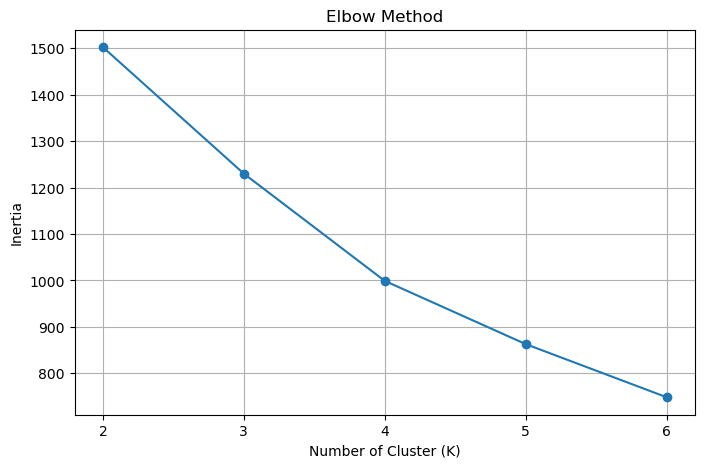

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize = (8,5))

plt.plot(
    list(k_values),
    inertia_values,
    marker = "o"
)

plt.xlabel("Number of Cluster (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.xticks(list(k_values))
plt.grid(True)

plt.show()


#### 11. VISUALIZATION OF SILHOUETTE RESULTS

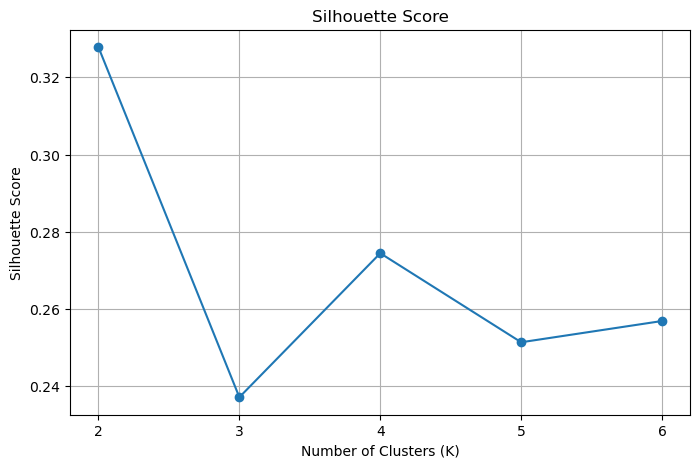

In [27]:

plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    silhouette_values,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")

plt.xticks(list(k_values))
plt.grid(True)

plt.show()

Summary: K-Means Evaluation Results


Inertia (Elbow Method): Measures cluster compactness (lower distance to centroids is better). Inertia drops as K increases, with the elbow point at K=4, indicating diminishing returns beyond 4 clusters.

Silhouette Score: Measures cluster separation and cohesion (higher score is better, range −1 to +1). K=2 scores highest (0.3278), though it reflects only moderate-to-weak cluster separation overall.

Key Takeaway: Mathematical metrics yield mixed recommendations (K=4 via Inertia vs. K=2 via Silhouette). The final choice of K should be decided by profiling the clusters against actual RFM feature averages to see which creates more actionable business segments.